<a href="https://colab.research.google.com/github/asmmorshed101/BanglaTextGeneration/blob/main/Pneumonia_with_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub pytorch-grad-cam

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset path:", path)

train_dir = os.path.join(path, "chest_xray/train")
val_dir   = os.path.join(path, "chest_xray/val")
test_dir  = os.path.join(path, "chest_xray/test")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

train_data = ImageFolder(train_dir, transform=transform)
val_data   = ImageFolder(val_dir, transform=transform)
test_data  = ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

print("Classes:", train_data.classes)

Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total


# Train
epochs = 3

for epoch in range(epochs):
    loss = train_one_epoch(train_loader)
    acc  = evaluate(val_loader)

    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {acc:.4f}")

Epoch 1 | Loss: 0.1121 | Val Acc: 0.9375
Epoch 2 | Loss: 0.0582 | Val Acc: 1.0000
Epoch 3 | Loss: 0.0472 | Val Acc: 0.7500


In [ ]:
test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.7259615384615384


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=0102bbadf7ee38d5f9f5e5b62c1222848883b19c048869c726e4eb8d22747f34
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

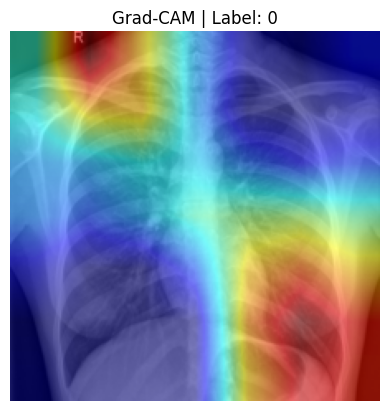

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

# target layer (ResNet last conv block)
target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

# sample image
img, label = test_data[10]

input_tensor = img.unsqueeze(0).to(device)

# generate heatmap
grayscale_cam = cam(input_tensor=input_tensor)[0]

# convert image
img_np = img.permute(1, 2, 0).numpy()

# overlay
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title(f"Grad-CAM | Label: {label}")
plt.axis('off')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving person100_bacteria_478.jpeg to person100_bacteria_478.jpeg


In [ ]:
from PIL import Image
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

img_path = "person100_bacteria_478.jpeg"
image = Image.open(img_path)

input_tensor = transform(image).unsqueeze(0).to(device)

In [ ]:
model.eval()

with torch.no_grad():
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

classes = train_data.classes
print("Prediction:", classes[pred.item()])

Prediction: PNEUMONIA


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

grayscale_cam = cam(input_tensor=input_tensor)[0]

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

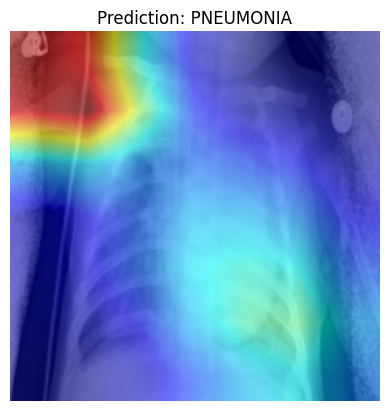

In [ ]:
# convert image to numpy
img_np = transform(image).permute(1,2,0).numpy()

# overlay heatmap
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title(f"Prediction: {classes[pred.item()]}")
plt.axis('off')